# Flow Matching on 2D Toy Datasets


We implement Flow Matching (Lipman et al., 2022).

## Setup

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.datasets import make_moons
from tqdm.auto import tqdm
import ot

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

## Datasets


In [7]:
def sample_moons(n, noise=0.05):
    X, _ = make_moons(n_samples=n, noise=noise)
    return torch.tensor(X, dtype=torch.float32)

def sample_gaussian_mixture(n, n_components=8, radius=3.0, std=0.3):
    angles = torch.linspace(0, 2 * np.pi, n_components + 1)[:-1]
    means = radius * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
    idx = torch.randint(0, n_components, (n,))
    return means[idx] + std * torch.randn(n, 2)

def sample_checkerboard(n, size=4):
    samples = []
    while len(samples) < n:
        x = torch.rand(n * 4, 2) * size - size / 2
        ix, iy = torch.floor(x[:, 0]).long(), torch.floor(x[:, 1]).long()
        samples.append(x[(ix + iy) % 2 == 0])
    return torch.cat(samples)[:n]

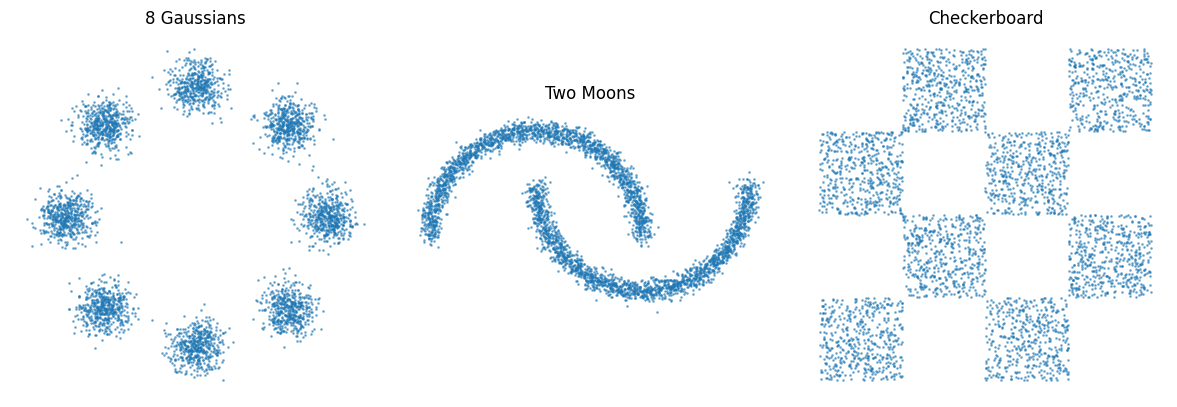

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="white")
datasets = [
    ("8 Gaussians", sample_gaussian_mixture(4000)),
    ("Two Moons", sample_moons(4000)),
    ("Checkerboard", sample_checkerboard(4000)),
]
for ax, (name, data) in zip(axes, datasets):
    ax.scatter(data[:, 0], data[:, 1], s=1, alpha=0.5)
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()

## Model

In [9]:
class VelocityMLP(nn.Module):

    def __init__(self, data_dim=2, hidden_dim=256, n_layers=4):
        super().__init__()
        layers = [nn.Linear(data_dim + 1, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, data_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        return self.net(torch.cat([x, t], dim=-1))

## Training



In [10]:
def train_flow_matching(model, sample_data_fn, n_steps=15_000, batch_size=512, lr=1e-3):
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    pbar = tqdm(range(n_steps), desc="Training")
    for step in pbar:
        x1 = sample_data_fn(batch_size).to(device)
        x0 = torch.randn_like(x1)
        t = torch.rand(batch_size, device=device)

        t_ = t.unsqueeze(-1)
        xt = (1 - t_) * x0 + t_ * x1
        target = x1 - x0

        pred = model(xt, t)
        loss = (pred - target).pow(2).mean()

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        losses.append(loss.item())
        if step % 500 == 0:
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    return losses

## Generation

Generate samples by solving the learned ODE from $t=0$ to $t=1$. Three solvers are implemented: Euler, Midpoint (2nd order), and RK4 (4th order).

In [11]:
@torch.no_grad()
def generate(model, n_samples=1000, n_steps=100, method="midpoint", return_trajectories=False):
    model.eval()
    dt = 1.0 / n_steps
    x = torch.randn(n_samples, 2, device=device)

    if return_trajectories:
        trajectory = [x.cpu().clone()]

    for i in range(n_steps):
        t = i * dt
        t_tensor = torch.full((n_samples,), t, device=device)

        if method == "euler":
            v = model(x, t_tensor)
            x = x + dt * v

        elif method == "midpoint":
            v = model(x, t_tensor)
            x_mid = x + (dt / 2) * v
            t_mid = torch.full((n_samples,), t + dt / 2, device=device)
            v_mid = model(x_mid, t_mid)
            x = x + dt * v_mid

        elif method == "rk4":
            t_half = torch.full((n_samples,), t + dt / 2, device=device)
            t_end = torch.full((n_samples,), t + dt, device=device)
            k1 = model(x, t_tensor)
            k2 = model(x + (dt / 2) * k1, t_half)
            k3 = model(x + (dt / 2) * k2, t_half)
            k4 = model(x + dt * k3, t_end)
            x = x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

        if return_trajectories:
            trajectory.append(x.cpu().clone())

    model.train()
    if return_trajectories:
        return x.cpu(), torch.stack(trajectory, dim=1)
    return x.cpu()

## Evaluation Metric

We use the Wasserstein-2 distance to quantitatively compare generated and true samples.

In [12]:
def compute_w2(generated, reference):
    n, m = len(generated), len(reference)
    a, b = np.ones(n) / n, np.ones(m) / m
    C = ot.dist(generated, reference, metric="sqeuclidean")
    return np.sqrt(ot.emd2(a, b, C))

## Plotting Helpers

In [13]:
def plot_progression(trajectories, n_steps, times, xlim, ylim, title=None):
    fig, axes = plt.subplots(1, len(times), figsize=(4.0 * len(times), 4.0), facecolor="white")
    for ax, t in zip(np.atleast_1d(axes), times):
        step_idx = min(int(round(t * n_steps)), trajectories.shape[1] - 1)
        pts = trajectories[:, step_idx].numpy()
        ax.scatter(pts[:, 0], pts[:, 1], s=2.0, alpha=0.4, linewidths=0)
        ax.set_title(f"t = {t:.2f}", fontsize=12)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_paths(trajectories, n_paths=150):
    traj = trajectories.numpy() if hasattr(trajectories, "numpy") else np.asarray(trajectories)
    idx = np.linspace(0, traj.shape[0] - 1, n_paths).astype(int)

    fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
    for i in idx:
        ax.plot(traj[i, :, 0], traj[i, :, 1], lw=0.8, alpha=0.12, color="#8A8A8A")
    ax.scatter(traj[idx, 0, 0], traj[idx, 0, 1], s=14, alpha=0.9, color="#0072B2", label="t = 0")
    ax.scatter(traj[idx, -1, 0], traj[idx, -1, 1], s=14, alpha=0.9, color="#D55E00", label="t = 1")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

## Experiment 1: Flow Matching Progression

Train on 8 Gaussians and Two Moons (15,000 steps, batch size 512), then visualise the distribution of generated samples at several values of $t$.

In [14]:
# 8 Gaussians
model_8g = VelocityMLP().to(device)
losses_8g = train_flow_matching(
    model_8g,
    sample_data_fn=lambda n: sample_gaussian_mixture(n),
    n_steps=15_000,
)

Training:   0%|          | 0/15000 [00:00<?, ?it/s]

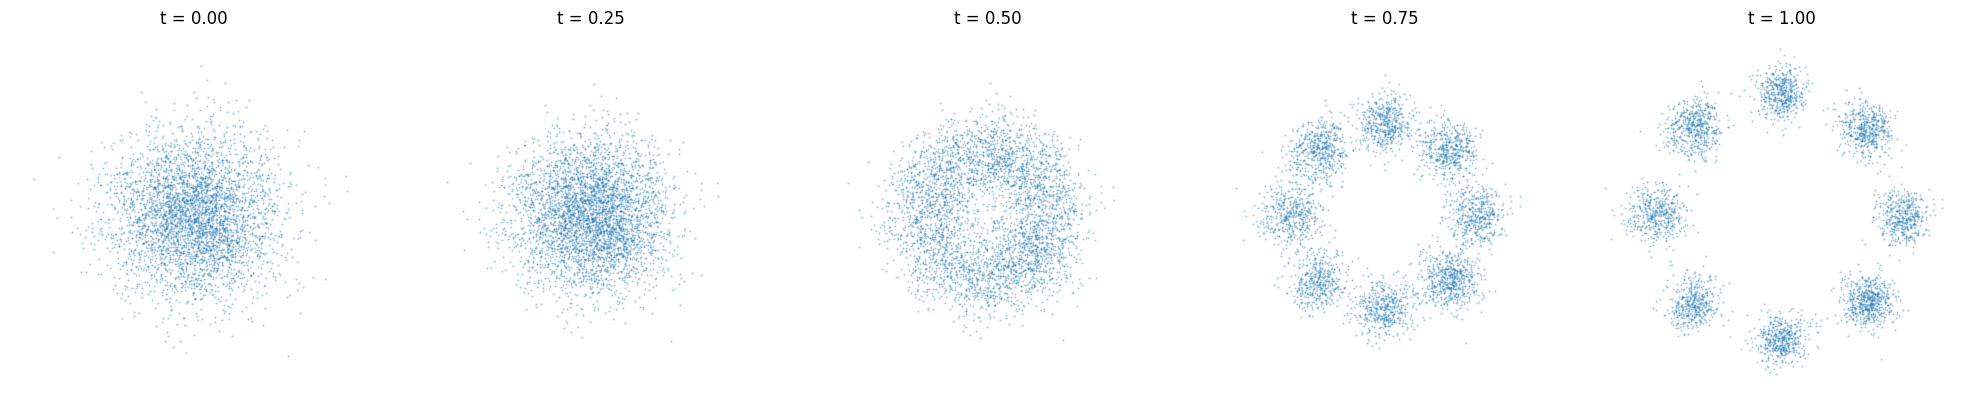

In [15]:
_, traj_8g = generate(model_8g, n_samples=4000, n_steps=250, method="midpoint", return_trajectories=True)
plot_progression(traj_8g, 250, np.linspace(0, 1, 5), xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))

In [16]:
# Two Moons
model_moons = VelocityMLP().to(device)
losses_moons = train_flow_matching(
    model_moons,
    sample_data_fn=lambda n: sample_moons(n, noise=0.05),
    n_steps=15_000,
)

Training:   0%|          | 0/15000 [00:00<?, ?it/s]

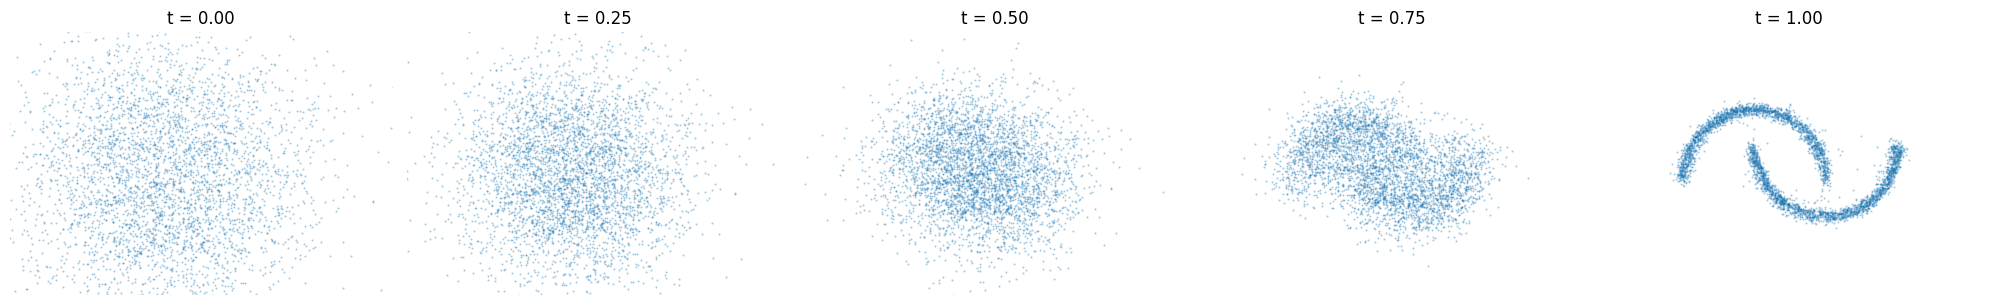

In [17]:
_, traj_moons = generate(model_moons, n_samples=4000, n_steps=250, method="midpoint", return_trajectories=True)
plot_progression(traj_moons, 250, np.linspace(0, 1, 5), xlim=(-2.2, 3.2), ylim=(-1.6, 2.1))

## Sample Paths

Trajectories of individual samples as they move from noise ($t=0$) to data ($t=1$).

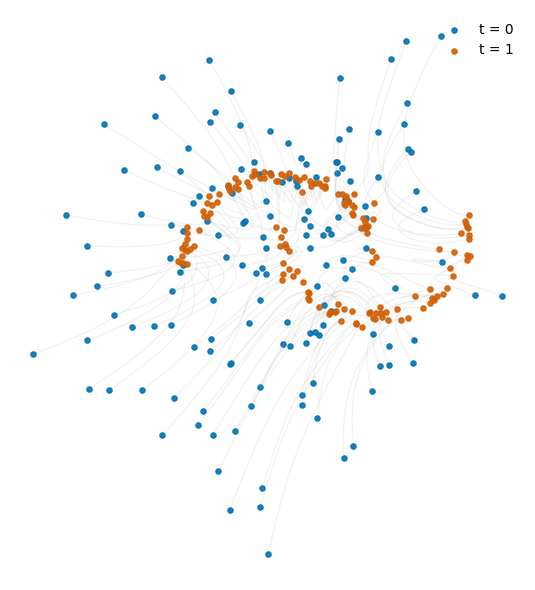

In [18]:
plot_paths(traj_moons, n_paths=150)

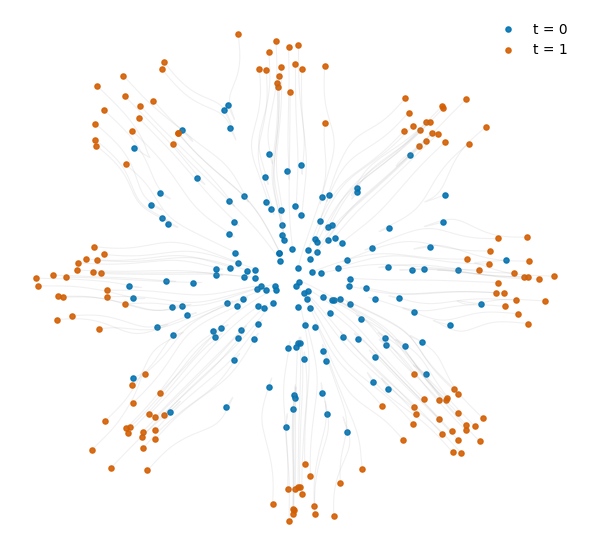

In [19]:
plot_paths(traj_8g, n_paths=150)

## Experiment 2: ODE Solver Comparison

We train on the Checkerboard distribution for only 5,000 steps to make the effect of solver choice more visible. For each solver, we generate 4,000 samples using between 1 and 25 integration steps and compute the $W_2$ distance to a reference set.

In [20]:
model_cb = VelocityMLP().to(device)
losses_cb = train_flow_matching(
    model_cb,
    sample_data_fn=sample_checkerboard,
    n_steps=5_000,
)

Training:   0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
torch.manual_seed(0)
reference_cb = sample_checkerboard(4_000).numpy()

torch.manual_seed(123)
ref2_cb = sample_checkerboard(4_000).numpy()
print(f"Baseline W2 (true vs true): {compute_w2(ref2_cb, reference_cb):.4f}")

solvers = ["euler", "midpoint", "rk4"]
step_counts = [1, 2, 3, 5, 10, 25]

results_cb = {s: [] for s in solvers}
for method in solvers:
    for n_steps in step_counts:
        torch.manual_seed(0)
        samples = generate(model_cb, n_samples=4000, n_steps=n_steps, method=method)
        w2 = compute_w2(samples.numpy(), reference_cb)
        results_cb[method].append(w2)
        print(f"{method:>10s}  steps={n_steps:>4d}  W2={w2:.4f}")

In [ ]:
colors = {"euler": "#D55E00", "midpoint": "#0072B2", "rk4": "#009E73"}

fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")
for method in solvers:
    ax.plot(step_counts, results_cb[method], "o-", color=colors[method],
            label=method.capitalize(), markersize=5)

ax.set_xlabel("Number of steps")
ax.set_ylabel("$W_2$")
ax.set_xscale("log")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()